In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from abc import ABC
from abc import abstractmethod
from dataclasses import dataclass

from numpy.typing import NDArray
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

Logistic regression is a linear regression adopted for classification with a sigmoid activation function applied to its ouputs. This is defined by the linear equation y = x * W + b, y is output, x is the input, W is the weights and b is bias. The output, y, is then passed through the sigmoid function and an appropriate threshold is applied. 

Regularisation is applied to prevent overfitting, this is controlled by the variable C in sci-kit. Regularisation can be L1 or L2 loss, for L1 you add the sum of the absolute values of the weights, and L2 is the sum of squared values of the weights. However because you train with gradient descent, these regularisation techniques are applied to the weight update step to reduce computation time. So L1 during gradiend descent is just the sign of the weights (1,0,-1) is added, for L2 the values of the weights are added. 

In [62]:
class Metrics():
    @staticmethod
    def binary_class_mean_acc(y_pred, y_true):
        n = len(y_true)
        total_ = (y_pred == y_true).sum()
        return total_ / n


@dataclass
class RegularisationMethod():
    l1:str = "l1"
    l2:str = "l2"
    none = None
    

class LogisticRegressionBase(ABC):
    def __init__(self, 
                 max_iterations:int=100,
                 regularisation:RegularisationMethod=RegularisationMethod.none, 
                 inv_regularisation_scalar:float=1.0):
        self.max_epochs = max_iterations
        self.regularisation_method = regularisation
        self.inv_regularisation_scalar = inv_regularisation_scalar

        # shape (1, n_params)
        self.weights:NDArray | None = None
        # ndarray of shape (1,) or (n_classes,)
        self.bias: float | None = None

    @abstractmethod
    def fit(self, X, Y):
        pass

    def _sigmoid(self,X) -> NDArray:
        return 1 / (1 + np.exp(-X))

    def _raw_pred(self, X):
        # X of shape (n_samples, n_features)
        # linear_ = self.weights @ np.hstack([X,np.ones((X.shape[0],1))]).T # make X -> [X,1]
        linear_ = self.weights @ X.T + self.bias
        return self._sigmoid(linear_).squeeze()

    def predict(self, X, threshold:float):
        return (self._raw_pred(X) > threshold).astype(np.int64)
        

class SciKitLogisticRegression(LogisticRegressionBase):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.log_model = LogisticRegression(
            penalty=self.regularisation_method,
            C=self.inv_regularisation_scalar,
            solver='saga',
            max_iter=self.max_epochs)
    
    def fit(self, X, Y):
        self.log_model.fit(X,Y)
        self.weights = self.log_model.coef_
        # self.weights = np.append(self.weights, self.log_model.intercept_)[None,:]
        self.bias = self.log_model.intercept_

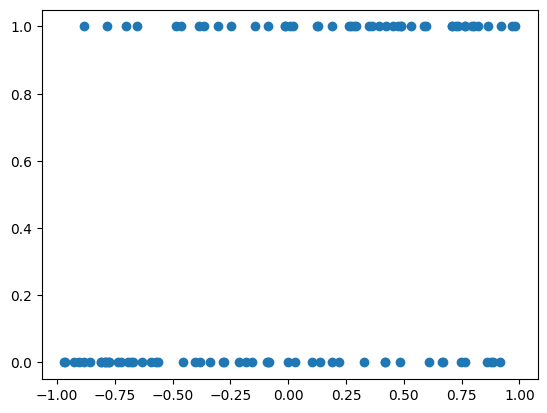

In [63]:
np.random.seed(44)
def get_noise_classification(sample_size:int, noise_scale=1.5):
    
    X = np.sort(np.random.uniform(low=-1, high=1, size=sample_size))
    y = (4.2 * X + np.random.randn(sample_size) * noise_scale + .5).reshape(-1)
    y = np.where(y > 0.5, 1, 0)
    return X[:,None],y
X,Y = get_noise_classification(100, noise_scale=5.5)
X_test, Y_test = get_noise_classification(120, noise_scale=8.5)
plt.scatter(X,Y)
# plt.scatter(X_test, Y_test)
# plt.plot(X, gradient*X+y_inter)
plt.show()

In [64]:
skLog = SciKitLogisticRegression()
skLog.fit(X,Y)

raw_pred = skLog._raw_pred(X)
scikit_raw_preds = skLog.log_model.predict_proba(X)[:,1]
scikit_preds = skLog.log_model.predict(X)
preds = skLog.predict(X, 0.5)

my_acc = Metrics.binary_class_mean_acc(preds, Y)
sk_acc = accuracy_score(Y, preds)

assert scikit_raw_preds.shape == raw_pred.shape, f'scikit_raw_preds.shape ({scikit_raw_preds.shape}) '\
    f' != raw_pred.shape ({raw_pred.shape})'
assert np.allclose(scikit_raw_preds, raw_pred), 'Raw scikit predictions differ to mine'
assert np.array_equal(scikit_preds, preds), 'Raw scikit predictions differ to mine'
assert np.isclose(my_acc, sk_acc), "Accuracy metric differs to Sklean"
print(f'All tests passed!')

All tests passed!


In [67]:
def run_logistic(logistic_regression:LogisticRegressionBase, regularisation:RegularisationMethod,
                 data=X, target=Y, test_data=X_test, test_target=Y_test):
    model = logistic_regression(regularisation=regularisation)
    model.fit(data, target)

    preds_train = model.predict(data, .5)
    preds_test = model.predict(test_data, .5)

    train_acc = Metrics.binary_class_mean_acc(preds_train, target)
    test_acc = Metrics.binary_class_mean_acc(preds_test, test_target)
    print(f'"{logistic_regression.__name__}" regularisation "{regularisation}" '\
          f'train acc {train_acc:.3f}, test acc {test_acc:.3f}')

run_logistic(SciKitLogisticRegression, RegularisationMethod.none)
run_logistic(SciKitLogisticRegression, RegularisationMethod.l1)
run_logistic(SciKitLogisticRegression, RegularisationMethod.l2)

"SciKitLogisticRegression" regularisation "None" train acc 0.680, test acc 0.633
"SciKitLogisticRegression" regularisation "l1" train acc 0.680, test acc 0.633
"SciKitLogisticRegression" regularisation "l2" train acc 0.680, test acc 0.642


In [101]:

class MyLogisticRegression(LogisticRegressionBase):

    def regularisation_derivative_wrt_w(self, weights):
        if self.regularisation_method == RegularisationMethod.none:
            return 0
        elif self.regularisation_method == RegularisationMethod.l1:
            return np.sign(weights)
        elif self.regularisation_method == RegularisationMethod.l2:
            return weights
    
    def fit(self, X, Y):
        dl_d_activation = lambda y_preds: (y_preds - Y)[:,None]
        d_dw = X
        d_db = 1
        lr = 0.02
        self.weights = np.random.randn(X.shape[1])
        self.bias = np.random.randn()

        for epoch_i in range(self.max_epochs):
            y_preds = self._raw_pred(X)

            d_dl = dl_d_activation(y_preds)
            # import pdb; pdb.set_trace()
            regularisation = self.regularisation_derivative_wrt_w(self.weights)
            self.weights -= lr * (d_dl * d_dw + regularisation).sum(axis=0)
            self.bias -= lr * (d_dl * d_db).sum(axis=0)

run_logistic(MyLogisticRegression, RegularisationMethod.none)
run_logistic(MyLogisticRegression, RegularisationMethod.l1)
run_logistic(MyLogisticRegression, RegularisationMethod.l2)


"MyLogisticRegression" regularisation "None" train acc 0.680, test acc 0.633
"MyLogisticRegression" regularisation "l1" train acc 0.670, test acc 0.633
"MyLogisticRegression" regularisation "l2" train acc 0.670, test acc 0.617


In [47]:
d_dw = np.random.randn(100,2)
d_dw * (np.ones((100,1))+1)

array([[-6.85571857e-01,  3.68975998e+00],
       [-9.31455916e-01, -2.06102306e+00],
       [ 3.37966639e+00, -2.01546315e+00],
       [ 1.44400660e+00, -6.22960555e-01],
       [-1.06513971e+00,  1.75319928e+00],
       [-2.61269085e+00, -2.21314130e-01],
       [ 2.16350579e+00,  1.50955389e+00],
       [-1.42952952e+00, -1.62239286e+00],
       [ 1.50578260e+00, -9.36921431e-01],
       [ 9.55859128e-01,  1.54564163e+00],
       [-3.36741333e+00,  1.99673630e+00],
       [-3.30767642e-01,  1.07645112e+00],
       [-2.78195848e-01,  4.62580182e-02],
       [ 2.74320517e+00,  2.25383586e+00],
       [ 1.42554235e+00, -1.87504579e+00],
       [-4.22781319e+00,  5.10156360e-01],
       [ 1.40015486e+00, -3.32057573e+00],
       [-3.38353488e+00, -2.80434644e+00],
       [-1.61330814e+00, -1.57125447e+00],
       [-1.55392554e-01,  2.04334687e+00],
       [ 2.08204204e+00, -5.74436179e-01],
       [-1.81726858e+00, -1.68717920e+00],
       [-1.05044653e+00, -1.93308764e+00],
       [-5.